# EE 344 — Assignment 5: Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cpu


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [3]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Fault counts: {'No Fault': 2365, 'LG': 1129, 'LL': 1004, 'LLG': 1134, 'LLL': 1096, 'LLLG': 1133}
Train size: 5502 | Test size: 2359


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [22]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 1000


In [24]:
## [ TODO 1 ]
# Define the DNN for Part 1 using PyTorch.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: linear (no activation)
# - Use BatchNorm and Dropout in hidden layers
#
# Write your model class below.

class DNN_Reg4(nn.Module):
    def __init__(self, input_dim=6, h1=16, h2=8, out_dim=4, p_drop=0.2):
        super().__init__()
        
        # Layer 1
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)
        
        # Layer 2
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)
        
        # Layer 3 / Output
        self.fc3 = nn.Linear(h2, out_dim)
        
    def forward(self, x):
        # Layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)
        
        # Output layer (linear)
        x = self.fc3(x)
        return x

In [26]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: MSE
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# TODO: model = ...
# TODO: loss_fn = ...
# TODO: optimizer = ...

# model = DNN_Reg4(...).to(device)
# loss_fn = ...
# optimizer = ...

# --- Model ---
model = DNN_Reg4(input_dim=6, h1=16, h2=8, out_dim=4, p_drop=0.2).to(device)

# --- Loss function ---
loss_fn = nn.MSELoss()

# --- Optimizer (Adam with L2 regularization via weight_decay) ---
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [40]:

# ----------------------------
# Training loop (you fill the key missing pieces)
# ----------------------------
## [ TODO 3 ]
def train_part1(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total_loss = 0.0
        total_samples = 0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # --- zero gradients ---
            optimizer.zero_grad()

            # --- forward pass ---
            preds = model(xb)

            # --- compute loss ---
            loss = loss_fn(preds, yb)

            # --- backward pass ---
            loss.backward()

            # --- optimizer step ---
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_samples += xb.size(0)

        # Print epoch and average loss at selected points
        if ep in [1, epochs//2, epochs]:
            avg_loss = total_loss / total_samples
            print(f"Epoch {ep}/{epochs} — Avg Loss: {avg_loss:.6f}")
            

@torch.no_grad()
def predict_part1(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    out = model(X_t).cpu().numpy()  # (N,4) real-valued
    return out

# TODO: Train the model
train_part1(model, train_loader_1, EPOCHS)


Epoch 1/1000 — Avg Loss: 0.628984
Epoch 500/1000 — Avg Loss: 0.093676
Epoch 1000/1000 — Avg Loss: 0.093221


In [42]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)

# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8294    0.8342    0.8318      2377
           C     1.0000    0.9258    0.9615      2263
           B     1.0000    0.9284    0.9628      3057
           A     0.9552    0.9768    0.9659      3144

   micro avg     0.9476    0.9212    0.9342     10841
   macro avg     0.9461    0.9163    0.9305     10841
weighted avg     0.9496    0.9212    0.9347     10841
 samples avg     0.6665    0.6520    0.6541     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2717  408]
 [ 394 1983]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3239    0]
 [ 168 2095]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2445    0]
 [ 219 2838]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2214  144]
 [  73 3071]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8236    0.8292    0.8264      1019
           C     1.0000    

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3

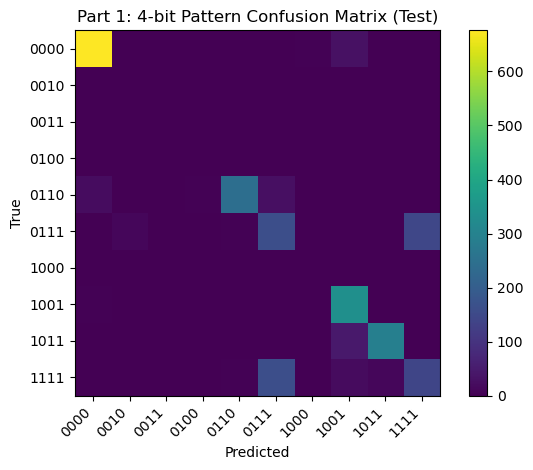

[[676   0   0   0   0   0   4  30   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [ 23   0   0   5 245  28   0   0   0   0]
 [  2  11   1   0   5 163   0   0   2 145]
 [  0   0   0   0   0   0   0   0   0   0]
 [  3   0   0   0   0   0   0 336   0   0]
 [  1   0   2   0   0   0   0  45 292   0]
 [  1   0   1   0   3 163   0  19  11 142]]


In [44]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)
#0000, 1001, 0011, 1011, 0111, 1111
#0110

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [46]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [48]:
## [ TODO 1 ]
# Define the DNN for Part 2.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: 4 logits (no sigmoid inside the model)
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiLabel4(nn.Module):
    def __init__(self, input_dim=6, h1=16, h2=8, out_dim=4, p_drop=0.2):
        super().__init__()
        # --- Layer 1 ---
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)
        
        # --- Layer 2 ---
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)
        
        # --- Output layer ---
        self.out = nn.Linear(h2, out_dim)  # logits, no activation here

    def forward(self, x):
        # Hidden layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)
        
        # Hidden layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)
        
        # Output layer
        logits = self.out(x)  # raw logits, shape (N, 4)
        return logits


In [50]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# TODO: model = ...
# TODO: loss_fn = ...
# TODO: optimizer = ...

## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# TODO: model = ...
# TODO: loss_fn = ...
# TODO: optimizer = ...

# --- Model ---
model = DNN_MultiLabel4(input_dim=6, h1=16, h2=8, out_dim=4, p_drop=0.2).to(device)

# --- Loss function ---
# BCEWithLogitsLoss handles raw logits directly (no sigmoid needed in the model)
loss_fn = nn.BCEWithLogitsLoss()

# --- Optimizer ---
# Adam with L2 regularization via weight_decay
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


In [52]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3]
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total_loss = 0.0
        total_samples = 0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device).float()  # ensure float for BCE

            # --- zero gradients ---
            optimizer.zero_grad()

            # --- forward pass ---
            logits = model(xb)

            # --- compute loss ---
            loss = loss_fn(logits, yb)

            # --- backward + step ---
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_samples += xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total_loss / total_samples
            print(f"Epoch {ep}/{epochs} — Avg Loss: {avg_loss:.6f}")


@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits


# --- Train the model ---
train_part2(model, train_loader_2, epochs=EPOCHS)


Epoch 1/1000 — Avg Loss: 0.707439
Epoch 500/1000 — Avg Loss: 0.185469
Epoch 1000/1000 — Avg Loss: 0.176998


In [54]:
# ----------------------------
# Evaluation
# ----------------------------
pred_bits_train_ = predict_bits_part2(model, X_train_s2)
pred_bits_test_  = predict_bits_part2(model, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8039    0.8936    0.8464      2377
           C     0.9990    0.9236    0.9598      2263
           B     0.9976    0.9359    0.9657      3057
           A     0.9997    0.9755    0.9874      3144

   micro avg     0.9505    0.9355    0.9430     10841
   macro avg     0.9501    0.9321    0.9398     10841
weighted avg     0.9560    0.9355    0.9446     10841
 samples avg     0.6620    0.6581    0.6554     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2607  518]
 [ 253 2124]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3237    2]
 [ 173 2090]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2438    7]
 [ 196 2861]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2357    1]
 [  77 3067]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8025    0.8930    0.8453      1019
           C     0.9945    

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3

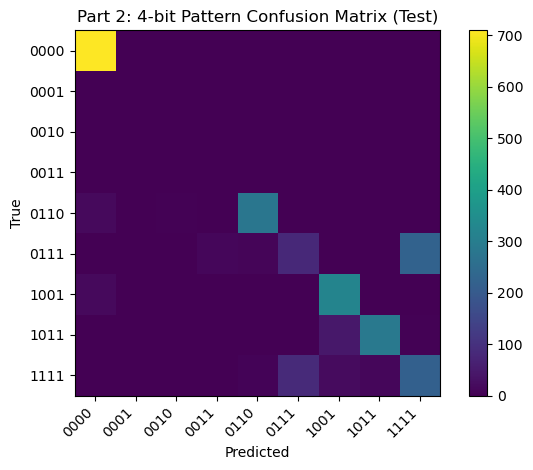

[[710   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 18   0   3   0 280   0   0   0   0]
 [  0   0   0  13   9  83   0   1 223]
 [ 18   1   0   0   0   0 320   0   0]
 [  0   0   0   0   0   0  47 288   5]
 [  0   0   0   0   6  84  21  12 217]]


In [56]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)
#0000, 1001, 0011, 1011, 0111, 1111
#0110
#0110

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [59]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [61]:
## [ TODO 1 ]
# Define the DNN for Part 3.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 6
# - Hidden activations: ReLU
# - Output: 6 logits
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()
        # Layer 1
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)
        
        # Layer 2
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)
        
        # Output layer
        self.out = nn.Linear(h2, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)
        
        logits = self.out(x)  # (N,6)
        return logits

In [63]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: CrossEntropyLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# TODO: model = ...
# TODO: loss_fn = ...
# TODO: optimizer = ...
# Model
model = DNN_MultiClass6(input_dim=X_train_s3.shape[1], h1=16, h2=8, num_classes=6, p_drop=DROPOUT_P).to(device)

# Loss function
loss_fn = nn.CrossEntropyLoss()  # expects logits (N,6) and integer labels (N,)

# Optimizer with L2 regularization
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # weight_decay = L2

In [65]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3 ]
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total_loss = 0.0
        total_samples = 0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # --- zero gradients ---
            optimizer.zero_grad()

            # --- forward pass ---
            logits = model(xb)

            # --- compute loss ---
            loss = loss_fn(logits, yb)

            # --- backward pass + optimizer step ---
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_samples += xb.size(0)

        # Print average loss at first, middle, last epochs
        if ep in [1, epochs//2, epochs]:
            avg_loss = total_loss / total_samples
            print(f"Epoch {ep}/{epochs} — Avg Loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()

# TODO: Train the model
train_part3(model, train_loader_3, EPOCHS)

Epoch 1/1000 — Avg Loss: 1.889490
Epoch 500/1000 — Avg Loss: 0.597004
Epoch 1000/1000 — Avg Loss: 0.584489



=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9484    1.0000    0.9735      1655
          LG     0.8464    0.9418    0.8916       790
          LL     0.9078    0.9388    0.9231       703
         LLG     0.8201    0.8841    0.8509       794
         LLL     0.5054    0.6701    0.5762       767
        LLLG     0.5072    0.1778    0.2633       793

    accuracy                         0.8026      5502
   macro avg     0.7559    0.7688    0.7464      5502
weighted avg     0.7847    0.8026    0.7799      5502



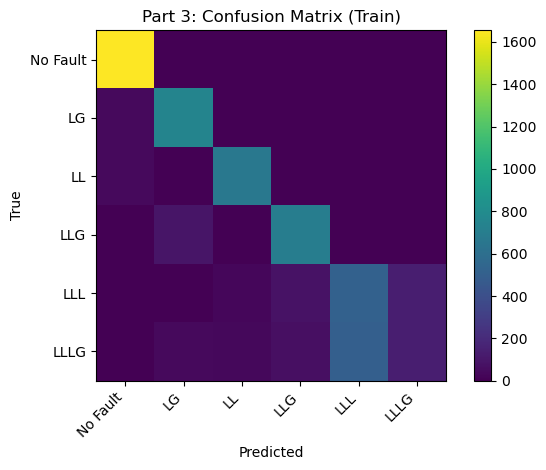


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9454    1.0000    0.9719       710
          LG     0.8391    0.9381    0.8858       339
          LL     0.9129    0.9402    0.9264       301
         LLG     0.8559    0.8735    0.8646       340
         LLL     0.5011    0.6930    0.5816       329
        LLLG     0.5128    0.1765    0.2626       340

    accuracy                         0.8037      2359
   macro avg     0.7612    0.7702    0.7488      2359
weighted avg     0.7888    0.8037    0.7816      2359



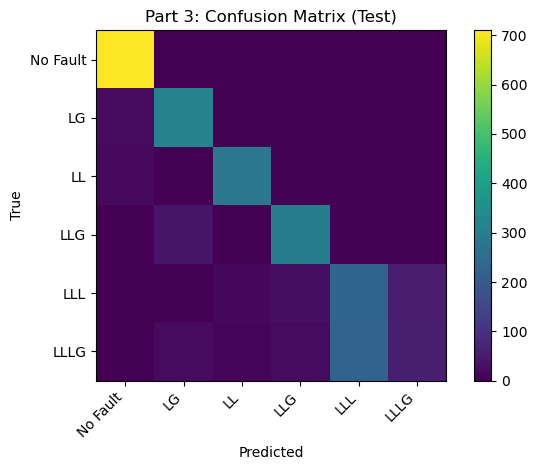

In [67]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model, X_train_s3)
pred_test  = predict_part3(model, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?
2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?
3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1:
- Q2:
- Q3:


Q1: Based on the calculated error metrics, the multi-label formulation fits this dataset best. The regression model is a very close second. This is evidenced by the near perfect f1 scores both models obtained across A, B, and C.

Q2: 0110 is a bit pattern that was predicted by both models in part 1 and 2. This does not exist in the dataset. This is not surprising as both models predict individual bits and aren't bound by the constraints set by input bit patterns. Individual predictions come together to give varied bit patterns. There are no built in corrections to avoid invalid bit patterns.

Q3: In the bit level modules we consistently see that models struggle with predicting the correct bit value for G. The multiclass model falters for classes LLL and LLLG. One plausible reason for this could be that not many instances of G = 1, LLL, and LLLG exist in the dataset. This causes the model to struggle at predicting the right values. 


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


In [73]:
import numpy as np

# y_bits shape: (N,4) with [G,C,B,A]

y_binary = (Y_bits.sum(axis=1) > 0).astype(int)
# 0 = No Fault
# 1 = Fault

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.30,
    stratify=y_binary,
    random_state=42
)

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

import torch
from torch.utils.data import TensorDataset, DataLoader

Xtr = torch.tensor(X_train_s, dtype=torch.float32)
Xte = torch.tensor(X_test_s, dtype=torch.float32)

ytr = torch.tensor(y_train, dtype=torch.float32)
yte = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(Xtr, ytr),
    batch_size=32,
    shuffle=True
)

import torch.nn as nn
import torch.nn.functional as F

class DNN_Binary(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(6,16)
        self.bn1 = nn.BatchNorm1d(16)
        self.drop1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(16,8)
        self.bn2 = nn.BatchNorm1d(8)
        self.drop2 = nn.Dropout(0.2)

        self.out = nn.Linear(8,1)

    def forward(self,x):

        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop2(x)

        return self.out(x)   # logits

model = DNN_Binary()

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

def train(model, loader, epochs=50):

    model.train()

    for ep in range(epochs):

        total = 0

        for xb,yb in loader:

            optimizer.zero_grad()

            logits = model(xb).squeeze()

            loss = loss_fn(logits, yb)

            loss.backward()

            optimizer.step()

            total += loss.item()*xb.size(0)

        if ep in [0, epochs//2, epochs-1]:
            print(f"Epoch {ep+1} loss {total/len(loader.dataset):.4f}")

train(model, train_loader)

@torch.no_grad()
def predict(model,X):

    model.eval()

    X_t = torch.tensor(X,dtype=torch.float32)

    logits = model(X_t).squeeze()

    probs = torch.sigmoid(logits)

    return (probs>=0.5).int().numpy()

from sklearn.metrics import classification_report, confusion_matrix

# Train
y_pred_train = predict(model,X_train_s)

print("TRAIN REPORT")
print(classification_report(y_train,y_pred_train))
print(confusion_matrix(y_train,y_pred_train))


# Test
y_pred_test = predict(model,X_test_s)

print("TEST REPORT")
print(classification_report(y_test,y_pred_test))
print(confusion_matrix(y_test,y_pred_test))

Epoch 1 loss 0.6198
Epoch 26 loss 0.1447
Epoch 50 loss 0.1261
TRAIN REPORT
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1655
           1       1.00      0.95      0.98      3847

    accuracy                           0.97      5502
   macro avg       0.95      0.98      0.96      5502
weighted avg       0.97      0.97      0.97      5502

[[1655    0]
 [ 174 3673]]
TEST REPORT
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       710
           1       1.00      0.96      0.98      1649

    accuracy                           0.97      2359
   macro avg       0.96      0.98      0.97      2359
weighted avg       0.98      0.97      0.98      2359

[[ 710    0]
 [  59 1590]]
